In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [4]:
df_index = pd.read_csv('economic_index.csv')
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [8]:
df_index.drop(columns=['Unnamed: 0','year','month'],inplace=True)

In [9]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [10]:
import seaborn as sns

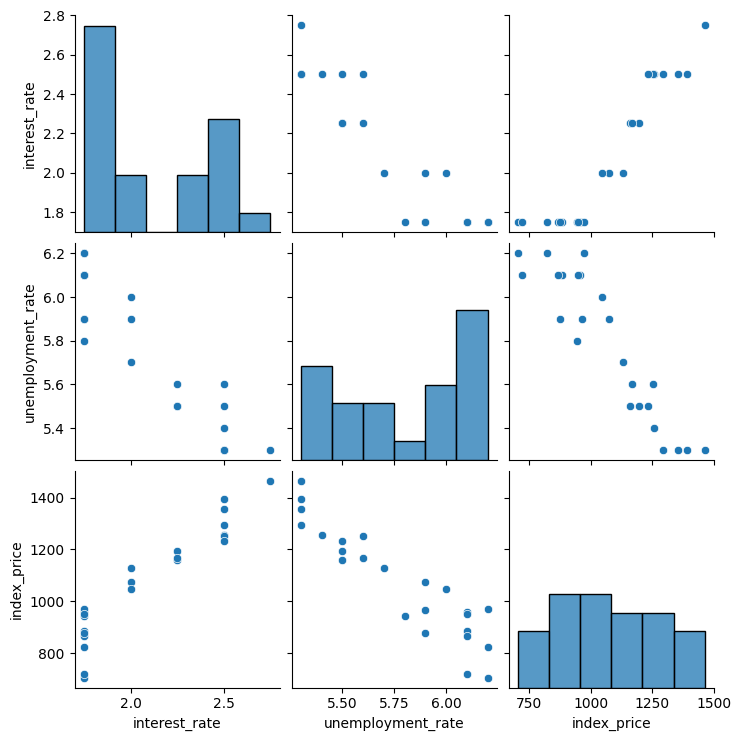

In [11]:
sns.pairplot(df_index)

In [12]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [35]:
#independent and dependent features
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [36]:
type(X)

pandas.core.frame.DataFrame

In [37]:
type(y)

pandas.core.series.Series

In [38]:
#train test split
from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

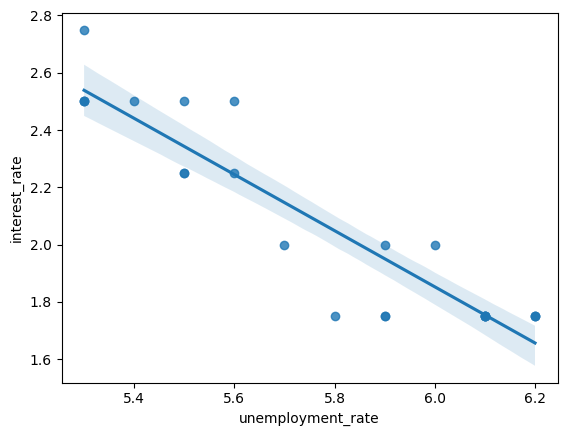

In [40]:
sns.regplot(x=df_index['unemployment_rate'],y=df_index['interest_rate'])

<Axes: xlabel='interest_rate', ylabel='index_price'>

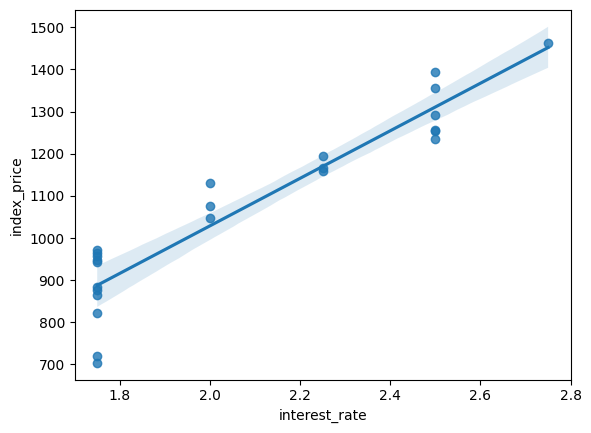

In [21]:
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [43]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [44]:
type(X_test)

numpy.ndarray

In [45]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression() 

In [46]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
from sklearn.model_selection import cross_val_score

In [51]:
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [52]:
np.mean(validation_score)

np.float64(-5914.828180162386)

In [53]:
y_pred = regression.predict(X_test)

In [54]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [55]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [56]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [57]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse,mae,rmse)

8108.567426306604 73.80444932337097 90.04758423359621


In [58]:
r_square = r2_score(y_test,y_pred)
print(r_square)

0.7591371539010257


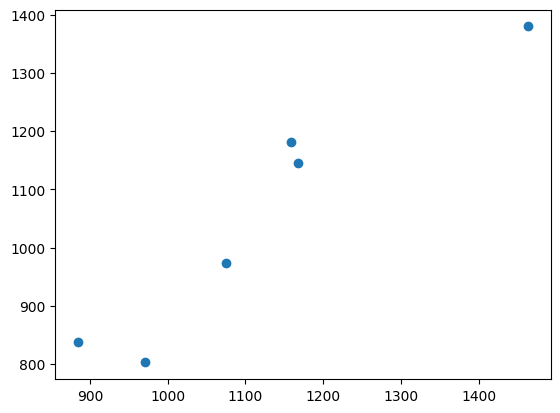

In [59]:
plt.scatter(y_test,y_pred)

In [60]:
residuals = y_test - y_pred
residuals

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64

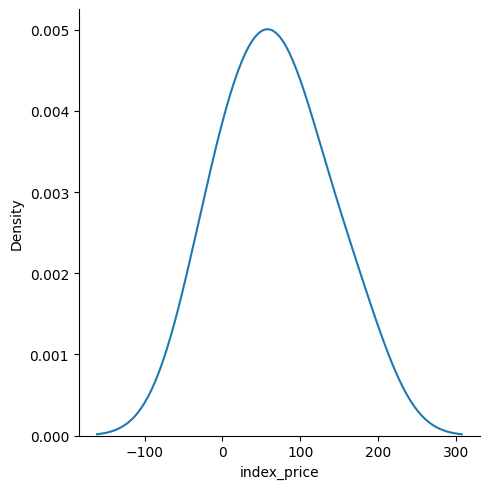

In [61]:
sns.displot(residuals,kind='kde')

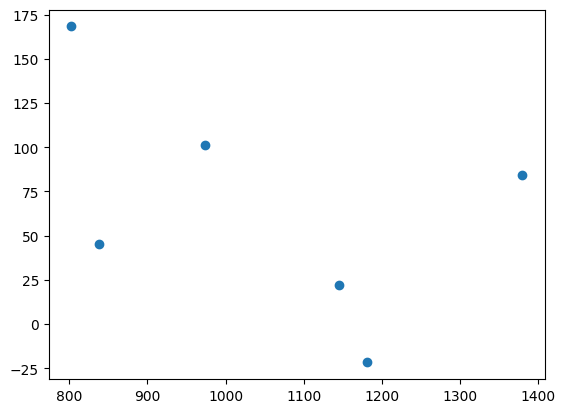

In [62]:
plt.scatter(y_pred,residuals)

In [63]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()

In [64]:
model.summary()

d:\Kunal_Learning_ML\Learning-ML\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 02 Oct 2025   Prob (F-statistic):                       0.754
Time:                        21:50:04   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""